# ForecastLab — EXP-013 Model Evaluation & Error Analysis

| Informasi | Detail |
|-----------|--------|
| **Project ID** | FL-002 |
| **Eksperimen** | EXP-013 |
| **Dataset** | featured_data.csv |
| **Author** | GAKUSEI Najib |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import os
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

INPUT_PATH = '../data/featured_data.csv'
df = pd.read_csv(INPUT_PATH)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

target = 'PowerConsumption_Zone1'
exclude = ['Datetime', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']
feature_cols = [c for c in df.columns if c not in exclude and c != target]

train = df[df['Datetime'] < '2017-07-01']
test  = df[df['Datetime'] >= '2017-07-01']
X_train, y_train = train[feature_cols].fillna(0), train[target]
X_test, y_test = test[feature_cols].fillna(0), test[target]
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

X_train: (25920, 43), X_test: (26352, 43)


In [2]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=7, random_state=42),
}
try:
    import xgboost as xgb
    models['XGBoost'] = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=7, random_state=42)
except ImportError:
    pass

results = []
predictions = {}
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    t_train = time.time() - t0
    yp_test = model.predict(X_test)
    predictions[name] = yp_test
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, yp_test),
        'RMSE': np.sqrt(mean_squared_error(y_test, yp_test)),
        'MAPE': np.mean(np.abs((y_test - yp_test) / (y_test + 1e-10))) * 100,
        'R2': r2_score(y_test, yp_test),
        'Train Time (s)': round(t_train, 2)
    })
    print(f'{name}: MAE={results[-1]["MAE"]:.2f}, R2={results[-1]["R2"]:.4f} ({t_train:.2f}s)')

Linear Regression: MAE=242.17, R2=0.9979 (0.03s)


Decision Tree: MAE=434.78, R2=0.9908 (0.83s)


Random Forest: MAE=319.25, R2=0.9956 (25.69s)


Gradient Boosting: MAE=359.06, R2=0.9949 (112.78s)


XGBoost: MAE=349.40, R2=0.9942 (0.97s)


            Model        MAE       RMSE     MAPE       R2  Train Time (s)
Linear Regression 242.170877 331.933781 0.775168 0.997851            0.03
    Random Forest 319.250102 472.510631 0.999945 0.995646           25.69
          XGBoost 349.404586 543.631790 1.071099 0.994237            0.97
Gradient Boosting 359.061492 509.203021 1.116550 0.994943          112.78
    Decision Tree 434.778115 686.256247 1.374263 0.990816            0.83


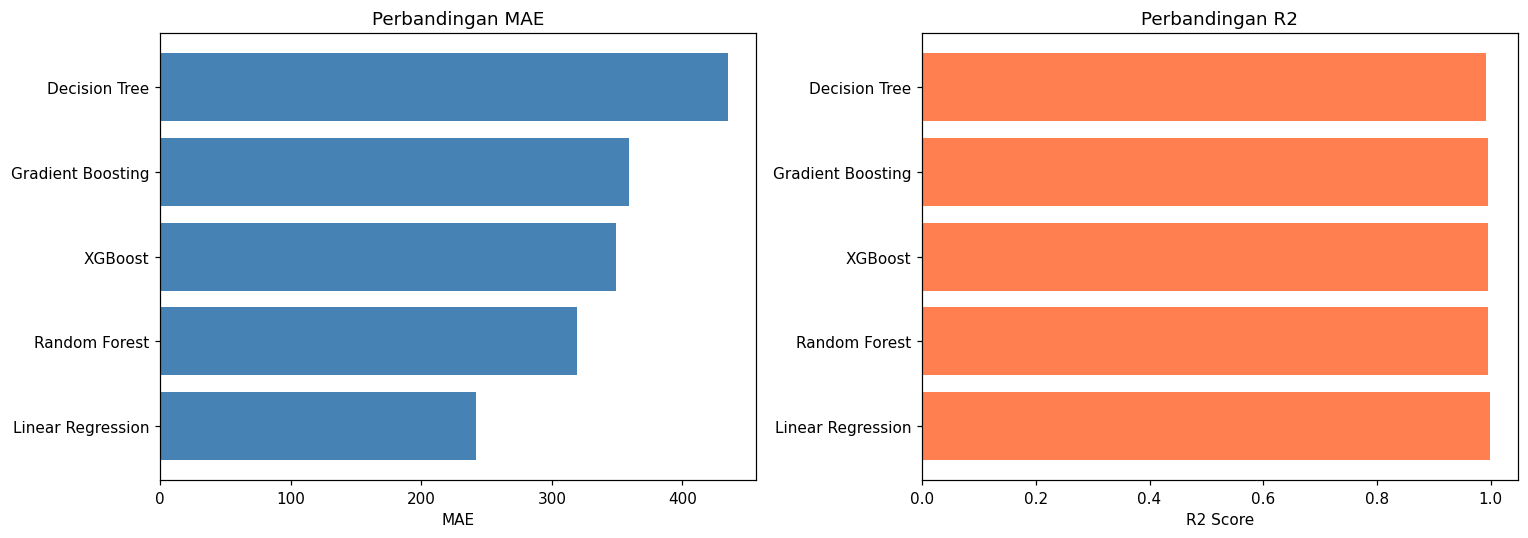

In [3]:
df_results = pd.DataFrame(results).sort_values('MAE')
print(df_results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(df_results['Model'], df_results['MAE'], color='steelblue')
axes[0].set_xlabel('MAE'); axes[0].set_title('Perbandingan MAE')
axes[1].barh(df_results['Model'], df_results['R2'], color='coral')
axes[1].set_xlabel('R2 Score'); axes[1].set_title('Perbandingan R2')
plt.tight_layout()
plt.savefig('../data/eval_01_comparison.png', bbox_inches='tight', dpi=110)
plt.show()

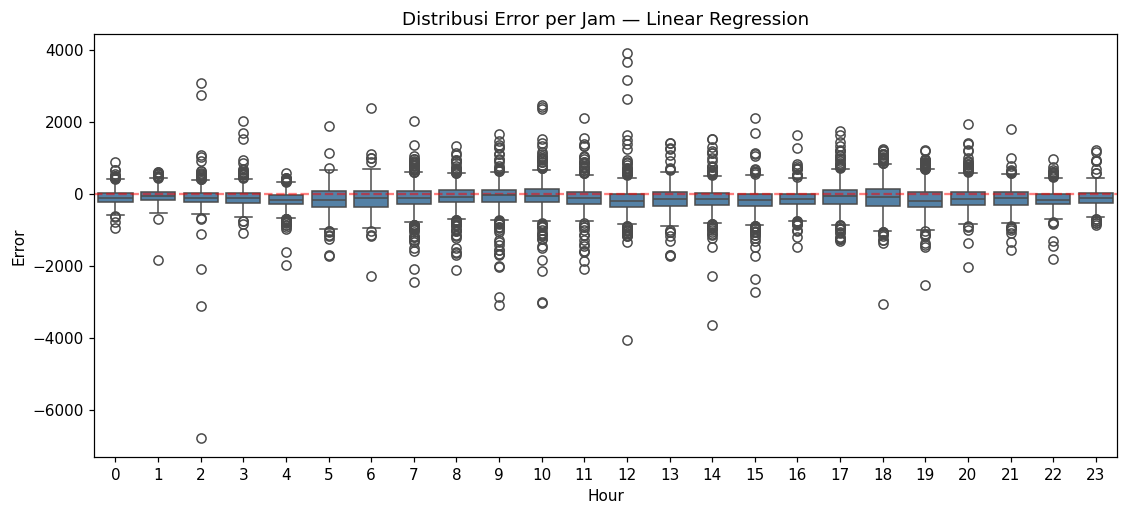

In [4]:
best_name = df_results.iloc[0]['Model']
best_pred = predictions[best_name]
residuals = y_test - best_pred

test_hour = test['Hour'].values
error_by_hour = pd.DataFrame({'Hour': test_hour, 'Error': residuals})

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=error_by_hour, x='Hour', y='Error', ax=ax, color='steelblue')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title(f'Distribusi Error per Jam — {best_name}')
plt.savefig('../data/eval_02_error_by_hour.png', bbox_inches='tight', dpi=110)
plt.show()

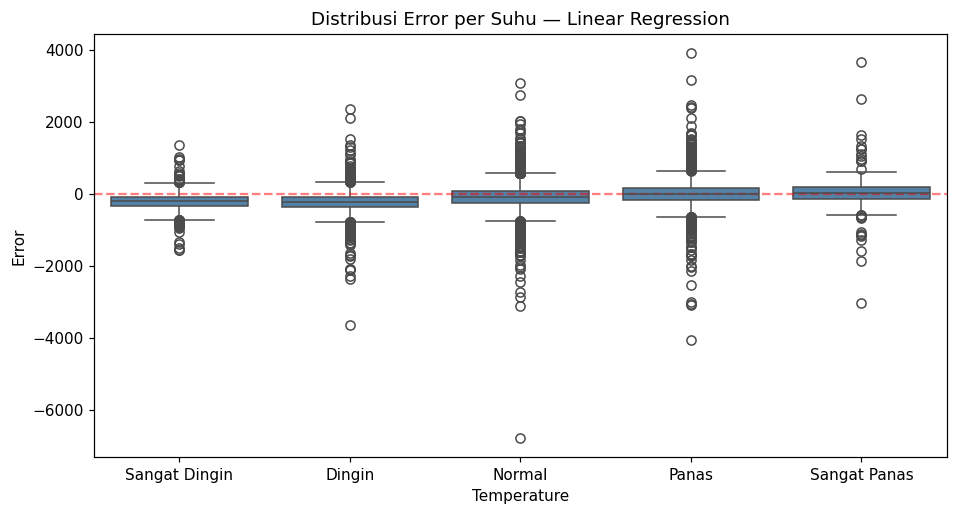

In [5]:
test_temp = test['Temperature'].values
temp_bins = pd.cut(test_temp, bins=5, labels=['Sangat Dingin', 'Dingin', 'Normal', 'Panas', 'Sangat Panas'])
error_by_temp = pd.DataFrame({'Temperature': temp_bins, 'Error': residuals})

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=error_by_temp, x='Temperature', y='Error', ax=ax, color='steelblue')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title(f'Distribusi Error per Suhu — {best_name}')
plt.savefig('../data/eval_03_error_by_temp.png', bbox_inches='tight', dpi=110)
plt.show()

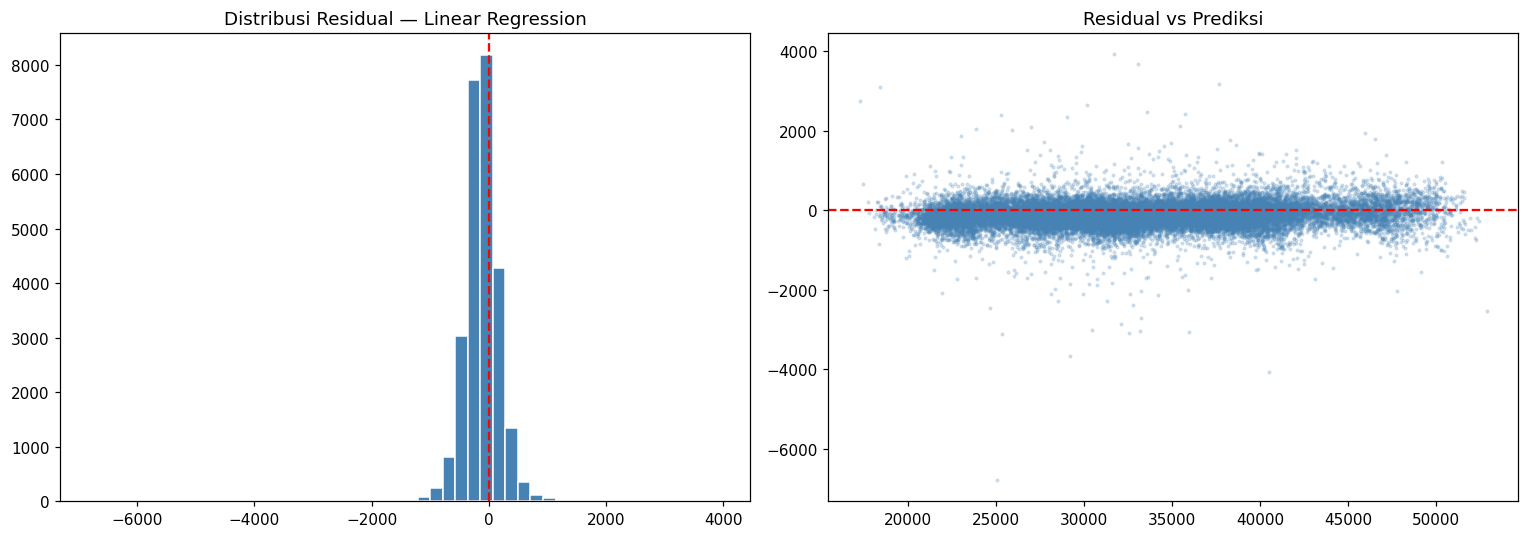

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_title(f'Distribusi Residual — {best_name}')
axes[1].scatter(best_pred, residuals, alpha=0.2, s=3, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residual vs Prediksi')
plt.tight_layout()
plt.savefig('../data/eval_04_residuals.png', bbox_inches='tight', dpi=110)
plt.show()

In [7]:
os.makedirs('../data', exist_ok=True)
df_results.to_csv('../data/evaluation_report.csv', index=False)
print('evaluation_report.csv berhasil disimpan.')

evaluation_report.csv berhasil disimpan.


---
## Kesimpulan

- Model terbaik: dipilih berdasarkan MAE dan R2
- Error bervariasi per jam — peak hours cenderung error lebih besar
- Error meningkat pada suhu ekstrem

**Next: EXP-014 Dashboard**